## Grupp4

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV

import seaborn as sns

# Ladda data
df = pd.read_csv('data/historical_data.csv')


EDA

In [13]:
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          12000 non-null  int64  
 1   day                         12000 non-null  int64  
 2   event_type                  12000 non-null  str    
 3   category                    12000 non-null  str    
 4   region                      11660 non-null  str    
 5   device                      12000 non-null  str    
 6   account_age_days            12000 non-null  float64
 7   num_prev_listings           12000 non-null  int64  
 8   prev_reports_30d            12000 non-null  int64  
 9   verification_level          12000 non-null  int64  
 10  price                       11182 non-null  float64
 11  num_images                  12000 non-null  int64  
 12  message_length              12000 non-null  int64  
 13  contains_off_platform       12000 non-null

In [14]:
target_counts = df['is_suspicious'].value_counts(normalize=True)
print(f"Fördelning:\n{target_counts}")

Fördelning:
is_suspicious
0    0.898
1    0.102
Name: proportion, dtype: float64


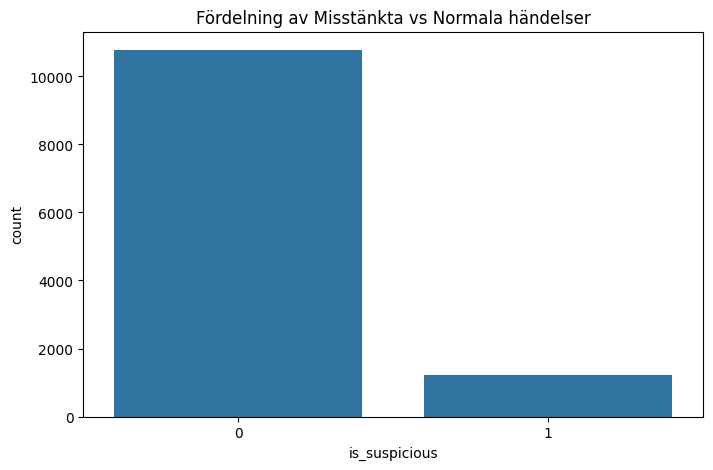

In [15]:
plt.figure(figsize=(8, 5))
sns.countplot(x='is_suspicious', data=df)
plt.title('Fördelning av Misstänkta vs Normala händelser')
plt.show()

In [16]:
missing_data = df.isnull().sum().sort_values(ascending=False)
print("\n--- Antal saknade värden per kolumn ---")
print(missing_data[missing_data > 0])



--- Antal saknade värden per kolumn ---
price                         818
time_to_first_response_min    590
region                        340
dtype: int64


In [17]:
print(df["region"].value_counts(dropna=False))

region
metro    5219
urban    4095
rural    2346
NaN       340
Name: count, dtype: int64


## Pipeline

In [19]:
target_name = "is_suspicious"
X = df.drop(columns=[target_name,"id"])
y = df[target_name]

# make numeric/category feature
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(include=["string"]).columns.tolist()


X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("numeric_features :", numeric_features)
print("\ncategorical_features :", categorical_features)

numeric_features : ['day', 'account_age_days', 'num_prev_listings', 'prev_reports_30d', 'verification_level', 'price', 'num_images', 'message_length', 'contains_off_platform', 'urgency_words', 'payment_attempt', 'time_to_first_response_min']

categorical_features : ['event_type', 'category', 'region', 'device']


## Pipeline

In [20]:



numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)

    ],
    remainder="drop"
)


In [21]:
#Test Area:
